# Student Success Analytics & Predictive Modeling
## Author : Yazan Maghary 
## Date : 06/05/2026
## Data_Source : Online School Learning Management System (LMS)
Understand student demographics through segmentation and predict course completion using high-dimensional engagement logs.
The project combines Unsupervised KMeans clustering and an iterative Keras Sequential Deep Learning model optimized with PCA.
Target variable: `passed_course` (Binary).

> Table of Contents : 
1. [Importing Libraries And Functions](#Importing-Libraries-And-Functions)
2. [Part 1: Data Loading and EDA for Clustering](#Part-1:-Data-Loading-and-EDA-for-Clustering)
3. [Part 1: KMeans Clustering & Hyperparameter Tuning](#Part-1:-KMeans-Clustering-&-Hyperparameter-Tuning)
4. [Part 1: Cluster Profiling & Explanatory Visualizations](#Part-1:-Cluster-Profiling-&-Explanatory-Visualizations)

# Importing Libraries And Functions

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
set_config(transform_output="pandas")

# Part 1

## Part 1: Data Loading and EDA for Clustering

### Load The Data

In [2]:
path = '../data/Option_B_clustering - Option_B_clustering.csv'
df = pd.read_csv(path)
df.head(5)

,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,assess_score_3,assess_score_4,assess_score_5
0,1,2,9,2,0,240,0,1,78,85,80,85,82
1,0,2,2,1,0,60,0,1,70,68,70,64,60
2,0,3,5,1,0,60,0,1,72,71,74,88,75
3,0,1,5,0,0,60,0,1,69,30,63,35,75
4,1,2,3,0,0,60,0,1,70,65,62,75,68


### Check for Missing Values And Duplicated ones

In [3]:
null_vals = df.isna()
dup_vals = df.duplicated()
print(f"Null Values:\n{null_vals.sum()}")
print('*'*50)
print('*'*50)
print(f"Duplicate Values:\n{dup_vals.sum()}")

Null Values:
gender                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
passed_course           0
assess_score_1          0
assess_score_2          0
assess_score_3          0
assess_score_4          0
assess_score_5          0
dtype: int64
**************************************************
**************************************************
Duplicate Values:
7


> No Nulls But There is 7 duplicated values that should be removed

In [4]:
# remove duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Check inconsistent data types , and inconsistent values

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 12730 entries, 0 to 12736
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   gender                12730 non-null  int64
 1   highest_education     12730 non-null  int64
 2   imd_band              12730 non-null  int64
 3   age_band              12730 non-null  int64
 4   num_of_prev_attempts  12730 non-null  int64
 5   studied_credits       12730 non-null  int64
 6   disability            12730 non-null  int64
 7   passed_course         12730 non-null  int64
 8   assess_score_1        12730 non-null  int64
 9   assess_score_2        12730 non-null  int64
 10  assess_score_3        12730 non-null  int64
 11  assess_score_4        12730 non-null  int64
 12  assess_score_5        12730 non-null  int64
dtypes: int64(13)
memory usage: 1.4 MB


In [6]:
df.describe()

,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,assess_score_3,assess_score_4,assess_score_5
count,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000
mean,0.446819,2.090102,4.407070,0.339199,0.107463,74.773763,0.091909,0.763001,73.987274,74.915240,79.734328,75.661822,78.106127
std,0.497183,0.940932,2.806379,0.488965,0.389890,37.459380,0.288909,0.425259,19.166495,14.654117,17.653542,17.967908,19.529946
min,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,2.000000,0.000000,0.000000,60.000000,0.000000,1.000000,66.000000,66.000000,69.000000,65.000000,67.000000
50%,0.000000,2.000000,4.000000,0.000000,0.000000,60.000000,0.000000,1.000000,77.000000,76.000000,81.000000,79.000000,80.000000
75%,1.000000,3.000000,7.000000,1.000000,0.000000,90.000000,0.000000,1.000000,86.000000,86.000000,95.000000,89.000000,96.000000
max,1.000000,4.000000,9.000000,2.000000,6.000000,630.000000,1.000000,1.000000,100.000000,100.000000,100.000000,100.000000,100.000000


> no inconsistent data types or values

### Scaled The Data for Clustering

In [7]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df) 
df_scaled.head(3)

,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,assess_score_3,assess_score_4,assess_score_5
0,1.112675,-0.095762,1.636668,3.396696,-0.275634,4.410984,-0.318137,0.557328,0.209370,0.688213,0.015050,0.519735,0.199387
1,-0.898735,-0.095762,-0.857748,1.351481,-0.275634,-0.394410,-0.318137,0.557328,-0.208042,-0.471916,-0.551431,-0.649062,-0.927132
2,-0.898735,0.967056,0.211288,1.351481,-0.275634,-0.394410,-0.318137,0.557328,-0.103689,-0.267187,-0.324839,0.686706,-0.159051


## Part 1: KMeans Clustering & Hyperparameter Tuning

### KMeans Clustering
* Selecting The best k from the elbow method and silhouette score

In [8]:
ks = range(2,11)
inertia = []
silhouette_scores = [] 
for k in ks : 
    kmean = KMeans(n_clusters=k , n_init='auto',random_state=42)
    kmean.fit(df_scaled)
    inertia.append(kmean.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled,kmean.labels_)) 
display(pd.DataFrame({'ks':ks , 'inertia':inertia , 'silhouette_scores':silhouette_scores}))

,ks,inertia,silhouette_scores
0,2,142965.329445,0.171663
1,3,133139.697224,0.094679
2,4,127510.000599,0.090562
3,5,119526.159505,0.094633
4,6,114944.286255,0.097579
5,7,110780.252080,0.096930
6,8,107229.475112,0.102499
7,9,99706.407451,0.114893
8,10,96979.195468,0.110487


Text(4, 0.15, 'Silhouette')

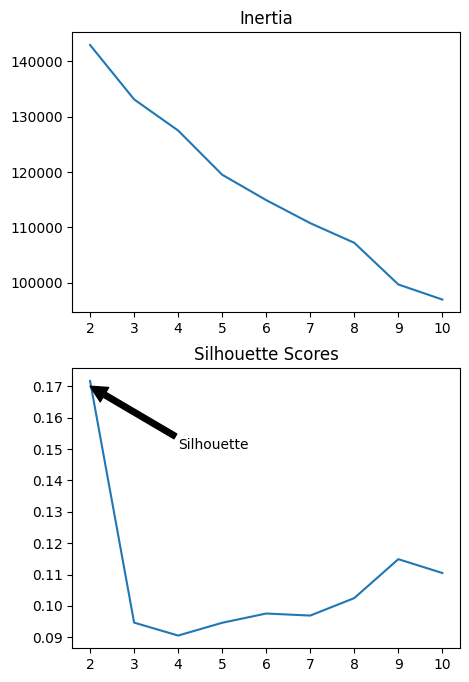

In [9]:
fig ,axes = plt.subplots(figsize=(5,8) , nrows=2 , ncols=1) 
axes[0].plot(ks , inertia)
axes[0].set_title('Inertia')
# axes[0].annotate('Elbow', xy=(3, 5500), xytext=(2, 3800), arrowprops=dict(facecolor='black'))
axes[1].plot(ks , silhouette_scores)
axes[1].set_title('Silhouette Scores') 
axes[1].annotate('Silhouette', xy=(2, 0.17), xytext=(4, 0.15), arrowprops=dict(facecolor='black'))

> we will process with k = 2  where is the silhouette score is the highest 

## Part 1: Cluster Profiling & Explanatory Visualizations
* Proccessed The Data With KMeans Clustering = 2

In [10]:
kmeans = KMeans(n_clusters=2 , n_init='auto',random_state=42)
kmeans.fit(df_scaled) 
df['cluster'] = kmeans.labels_

In [11]:
cluster_group = df.groupby('cluster',as_index=False).mean()
cluster_group

,cluster,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,assess_score_3,assess_score_4,assess_score_5
0,0,0.429097,2.158195,4.702375,0.372565,0.078622,71.638955,0.075178,0.909145,79.685748,80.577316,86.642518,83.345962,86.294181
1,1,0.481439,1.957077,3.830162,0.274014,0.163805,80.897912,0.124594,0.477494,62.854756,63.853828,66.238515,60.650116,62.109977


### Explanatory Analysis of KMeans Clusters

In [12]:
display(df.info(),df.head(3))

<class 'pandas.DataFrame'>
Index: 12730 entries, 0 to 12736
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   gender                12730 non-null  int64
 1   highest_education     12730 non-null  int64
 2   imd_band              12730 non-null  int64
 3   age_band              12730 non-null  int64
 4   num_of_prev_attempts  12730 non-null  int64
 5   studied_credits       12730 non-null  int64
 6   disability            12730 non-null  int64
 7   passed_course         12730 non-null  int64
 8   assess_score_1        12730 non-null  int64
 9   assess_score_2        12730 non-null  int64
 10  assess_score_3        12730 non-null  int64
 11  assess_score_4        12730 non-null  int64
 12  assess_score_5        12730 non-null  int64
 13  cluster               12730 non-null  int32
dtypes: int32(1), int64(13)
memory usage: 1.4 MB


None

,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,assess_score_3,assess_score_4,assess_score_5,cluster
0,1,2,9,2,0,240,0,1,78,85,80,85,82,0
1,0,2,2,1,0,60,0,1,70,68,70,64,60,1
2,0,3,5,1,0,60,0,1,72,71,74,88,75,0


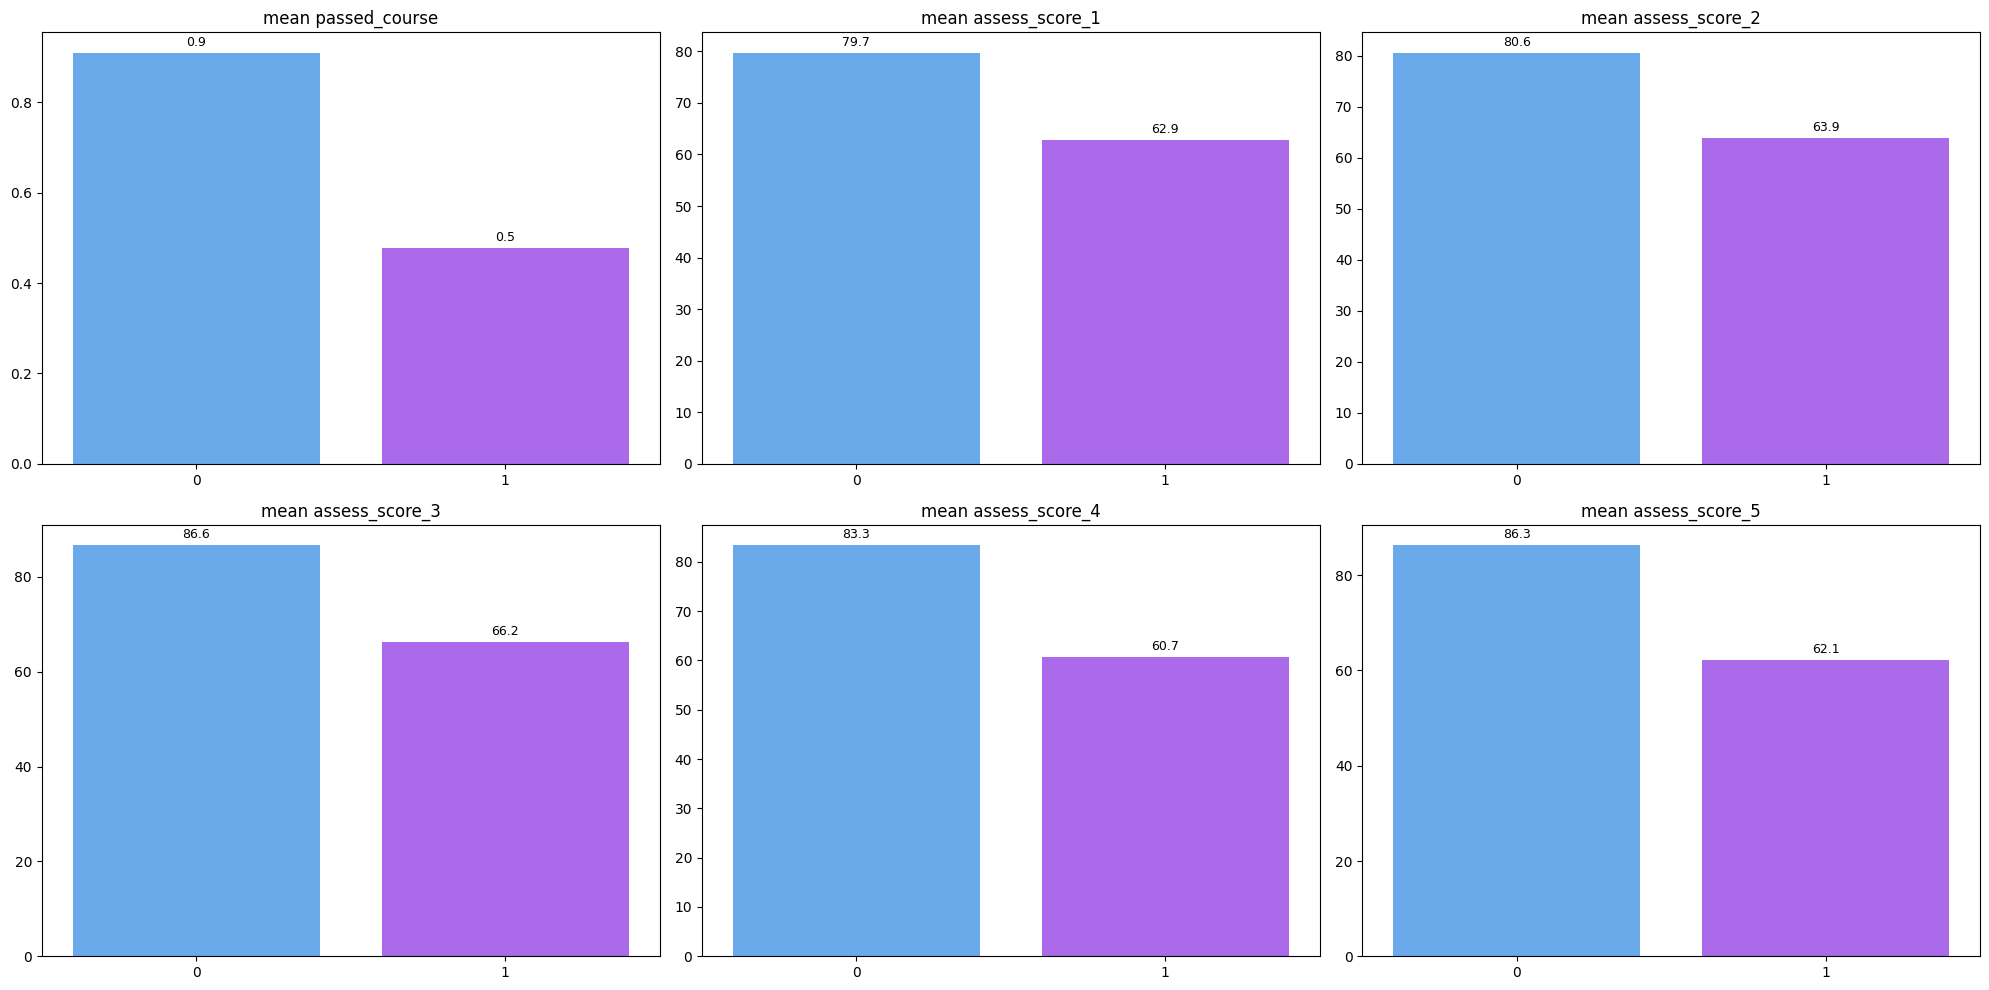

In [13]:
fig ,axes = plt.subplots(figsize=(20,10) , ncols=3 , nrows=2)
axes = axes.ravel()
for i ,col in enumerate(cluster_group.columns[-6:]): # 1 to exclude cluster 
    sns.barplot(x=cluster_group['cluster'] , y=cluster_group[col] , hue='cluster' ,legend=False, data=cluster_group , ax=axes[i], palette='cool') # palette coold color 
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_title(f'mean {col}')
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

### 📊 Cluster Analysis & Group Profiling

Based on the behavioral and academic trends visualized above, the KMeans model successfully segments the student population into two distinct behavioral archetypes:

#### 1. 🌟 Cluster 0: The Top Performers (High-Success Cohort)
* **Academic Performance:** This cohort maintains an exceptional academic track record, consistently securing high averages across all five assessments, ranging from **79.7% to 86.6%**.
* **Course Outcomes:** They have a commanding success rate, with **90%** of these students successfully passing the course. 
* **Strategic Value:** This group serves as the school's benchmark for academic success. Their habits represent the ideal student journey on the learning platform.

#### 2. ⚠️ Cluster 1: The Bottom Performers (High-Risk Cohort)
* **Academic Performance:** This cohort struggles academically from the outset. Their scores are significantly depressed, averaging between **60.7% and 66.2%** across all five assessments.
* **Course Outcomes:** They are a critically high-risk group with only a **50% pass rate**, meaning a student falling into this cluster has a literal coin-flip chance of failing the course.
* **Strategic Value:** This group identifies the exact subset of students requiring immediate institutional intervention. Because their scores drop as early as `assess_score_1` (62.9%), they can be proactively targeted for tutoring or outreach before they fall too far behind.

In [14]:
df.head()


,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,assess_score_3,assess_score_4,assess_score_5,cluster
0,1,2,9,2,0,240,0,1,78,85,80,85,82,0
1,0,2,2,1,0,60,0,1,70,68,70,64,60,1
2,0,3,5,1,0,60,0,1,72,71,74,88,75,0
3,0,1,5,0,0,60,0,1,69,30,63,35,75,1
4,1,2,3,0,0,60,0,1,70,65,62,75,68,1


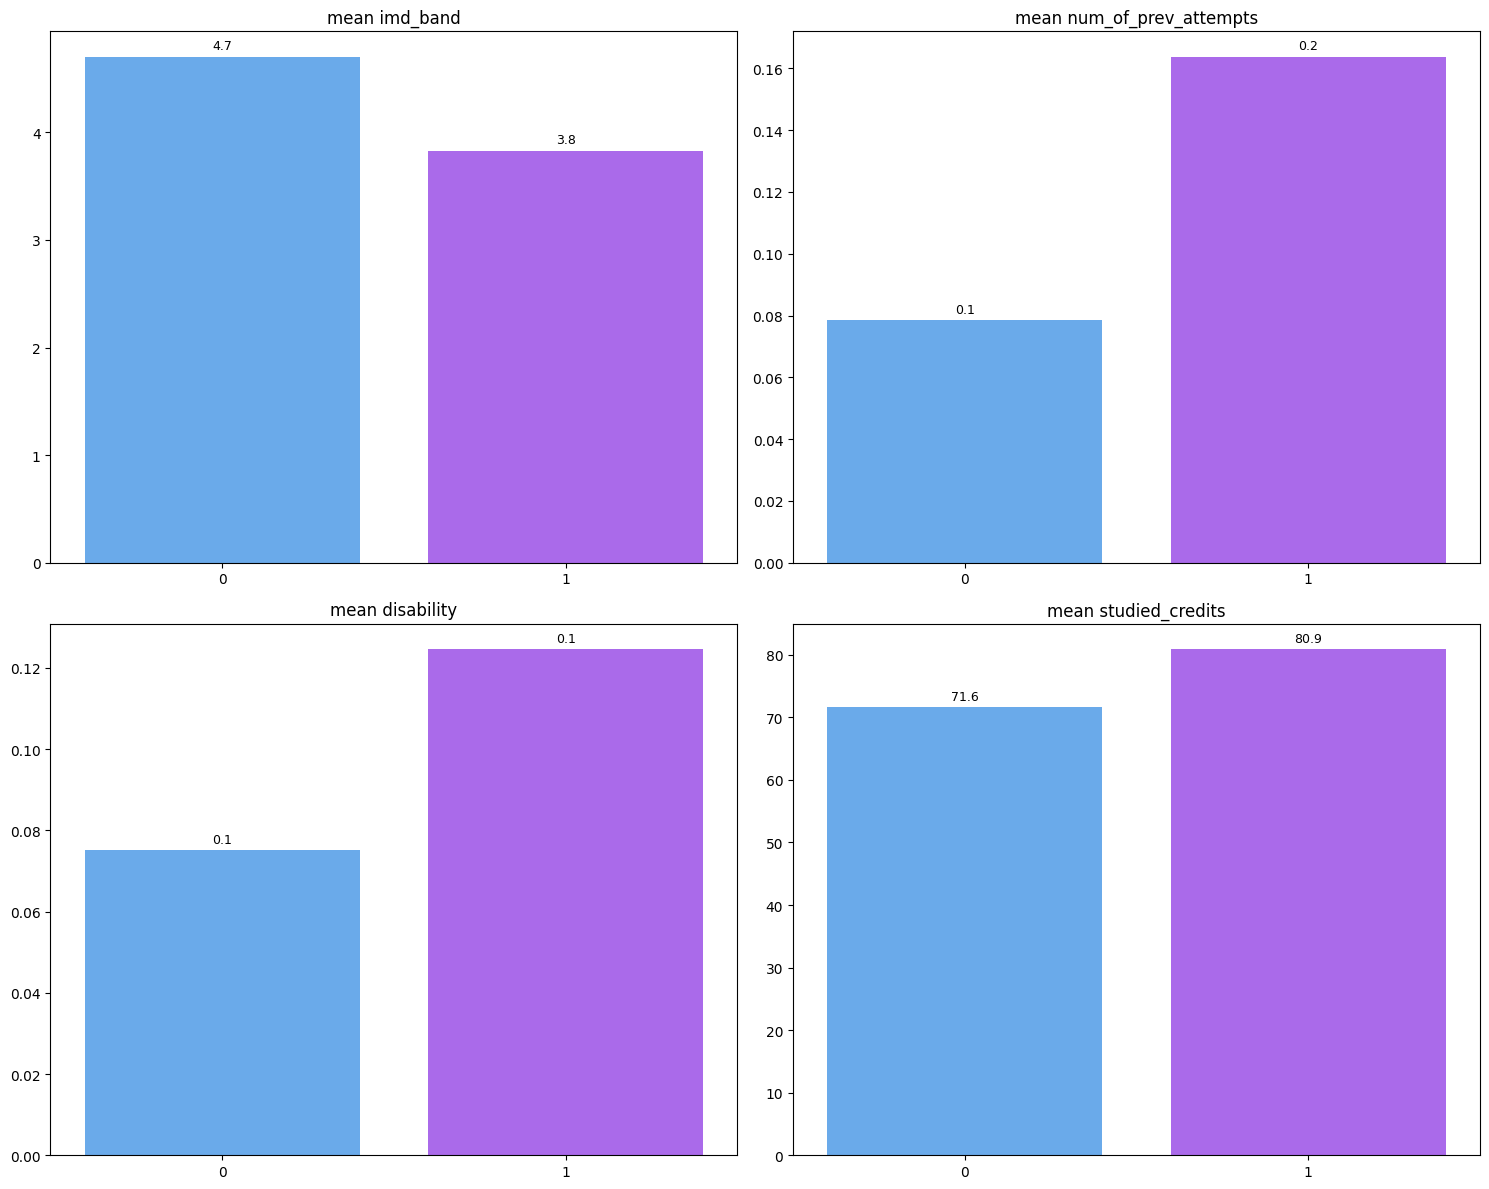

In [15]:
fig ,axes = plt.subplots(figsize=(15,12) , ncols=2 , nrows=2)
target_columns = ['imd_band', 'num_of_prev_attempts' , 'disability' , 'studied_credits']
axes = axes.ravel()
for i ,col in enumerate(target_columns): # 1 to exclude cluster 
    sns.barplot(x=cluster_group['cluster'] , y=cluster_group[col] , hue='cluster' ,legend=False, data=cluster_group , ax=axes[i], palette='cool') # palette coold color 
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_title(f'mean {col}')
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

### Visualization 2 Interpretation: Socioeconomic & Behavioral Demographics

While the first visualization established the academic success gap, this second visualization uncovers the underlying socioeconomic and demographic drivers that distinguish the two groups (**Cluster 0** in blue, **Cluster 1** in purple).

* **Socioeconomic Deprivation (`mean imd_band`):** Cluster 0 students come from less deprived, more affluent neighborhoods on average (IMD = **4.7**), whereas Cluster 1 students reside in areas with higher structural deprivation (IMD = **3.8**). Lower socioeconomic stability correlates strongly with the academic obstacles observed in the high-risk cohort.
* **Academic Redundancy (`mean num_of_prev_attempts`):** Students in Cluster 1 have double the rate of previous course attempts (**0.2**) compared to Cluster 0 (**0.1**). This indicates that Cluster 1 contains a high density of repeating students who are chronically hitting a wall with the course material.
* **Support Needs (`mean disability`):** The average disability index is higher in Cluster 1 (**0.12**) than in Cluster 0 (**0.07**). This indicates that the struggling cluster includes a higher proportion of students navigating learning adjustments or health challenges, requiring systemic institutional accommodations.
* **Course Workload Overload (`mean studied_credits`):** Cluster 1 students take on a higher credit burden on average (**80.9 credits**) than Cluster 0 students (**71.6 credits**). 

### 💡 Combined Strategic Business Insights for School Leadership
The data paints a clear picture: Cluster 1 is not failing due to a lack of talent or interest, but because they are **overburdened and under-supported**. They are more likely to come from deprived areas, juggle a higher course load (more credits), manage disabilities, and carry the stress of a previously failed attempt.

**Recommended Action Plan:**
1. **Credit Caps & Advising:** Prevent repeating students or students from high-deprivation bands from over-registering beyond 70 credits unless they pass a mid-term milestone.
2. **Proactive Resource Allocation:** Use the structural profile of Cluster 1 to automatically trigger financial aid outreach, hardware lending schemes, and disability support services during orientation week.